In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class MyText(TypedDict):
    original_text: str
    processed_text: str
    length_text: int

In [3]:
def to_lowercase(state: MyText) -> MyText:
    print("Converting to lower case........")
    lowercase_text = state["original_text"].lower()
    return {"processed_text": lowercase_text}

def calculate_length(state: MyText) -> MyText:
    print("Calculating length of text........")
    length = len(state["processed_text"])
    return {"length_text": length}

In [4]:
# Build the graph

graph = StateGraph(MyText)

# Add nodes to the graph
graph.add_node("lowercase", to_lowercase)
graph.add_node("length", calculate_length)

# Add edges to the graph
graph.add_edge(START, "lowercase")
graph.add_edge("lowercase", "length")
graph.add_edge("length", END)

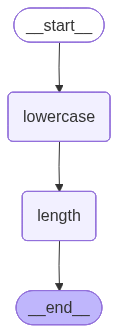

In [5]:
# Compile the graph
app = graph.compile()
app

In [8]:
# Run the graph
initial_state = {"original_text": "Hello, AVI!"}
result = app.invoke(initial_state)

Converting to lower case........
Calculating length of text........


In [9]:
result

{'original_text': 'Hello, AVI!',
 'processed_text': 'hello, avi!',
 'length_text': 11}